# 第17章: 回帰診断法

## 学習目標
- 残差分析を実行できる
- 影響度指標（クックの距離、てこ比）を計算・解釈できる
- 不均一分散の検定を行える
- 正規性の検定を理解する

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 17.1 残差分析

### 残差の種類
1. **通常残差**: $e_i = y_i - \hat{y}_i$

2. **標準化残差**: $r_i = \frac{e_i}{\hat{\sigma}}$

3. **内部スチューデント化残差**:
   $$t_i = \frac{e_i}{\hat{\sigma}\sqrt{1 - h_{ii}}}$$

4. **外部スチューデント化残差**:
   $$t_i^* = \frac{e_i}{\hat{\sigma}_{(i)}\sqrt{1 - h_{ii}}}$$
   
   ここで $\hat{\sigma}_{(i)}$ は $i$ 番目の観測値を除いて計算した標準誤差

In [2]:
# データ生成と回帰モデル
np.random.seed(123)

n = 100
X = np.random.uniform(0, 10, n)
Y = 2 + 3*X + np.random.normal(0, 2, n)

# Add outliers
Y[10] = 50   # Y outlier
Y[50] = -10  # Y outlier
X[90] = 15   # Leverage point
Y[90] = 2 + 3*15 + np.random.normal(0, 2)

# Fit regression
X_design = np.column_stack([np.ones(n), X])
beta = np.linalg.lstsq(X_design, Y, rcond=None)[0]
Y_hat = X_design @ beta
residuals = Y - Y_hat

# Calculate hat matrix diagonal
H = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T
leverage = np.diag(H)

# MSE and standard error
MSE = np.sum(residuals**2) / (n - 2)
sigma_hat = np.sqrt(MSE)

# Standardized residuals
std_residuals = residuals / sigma_hat

# Internally studentized residuals
int_student = residuals / (sigma_hat * np.sqrt(1 - leverage))

# Externally studentized residuals
ext_student = np.zeros(n)
for i in range(n):
    # MSE without observation i
    MSE_i = (np.sum(residuals**2) - residuals[i]**2/(1-leverage[i])) / (n - 3)
    ext_student[i] = residuals[i] / (np.sqrt(MSE_i * (1 - leverage[i])))

print("残差の種類")
print("="*50)
print(f"\n{'観測値':>8} {'残差':>10} {'標準化':>10} {'内部st':>10} {'外部st':>10}")
print("-"*55)
for i in [10, 50, 90, 0, 1]:  # Show outliers and normal points
    print(f"{i:>8} {residuals[i]:>10.3f} {std_residuals[i]:>10.3f} "
          f"{int_student[i]:>10.3f} {ext_student[i]:>10.3f}")

残差の種類

     観測値         残差        標準化       内部st       外部st
-------------------------------------------------------
      10     37.386      8.208      8.266     14.943
      50    -16.025     -3.518     -3.575     -3.814
      90     -0.575     -0.126     -0.137     -0.136
       0      3.994      0.877      0.883      0.882
       1     -0.012     -0.003     -0.003     -0.003


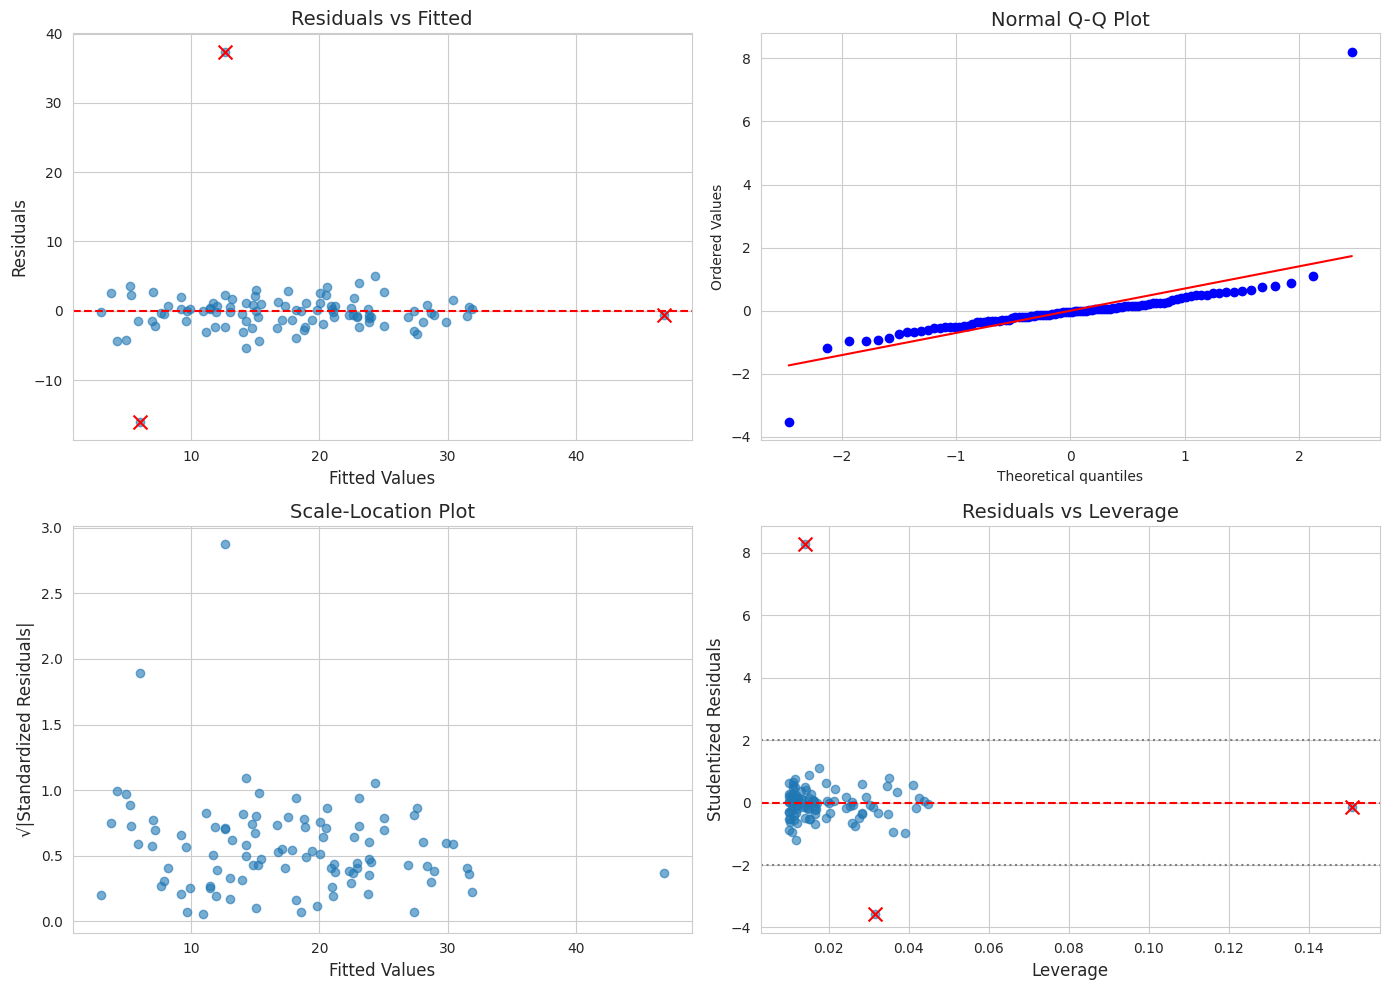

In [3]:
# 残差プロットの作成
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
axes[0, 0].scatter(Y_hat, residuals, alpha=0.6)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].scatter(Y_hat[[10, 50, 90]], residuals[[10, 50, 90]], 
                   color='red', s=100, marker='x')
axes[0, 0].set_xlabel('Fitted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Residuals vs Fitted', fontsize=14)

# Q-Q plot
stats.probplot(std_residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot', fontsize=14)

# Scale-Location plot
axes[1, 0].scatter(Y_hat, np.sqrt(np.abs(int_student)), alpha=0.6)
axes[1, 0].set_xlabel('Fitted Values', fontsize=12)
axes[1, 0].set_ylabel('√|Standardized Residuals|', fontsize=12)
axes[1, 0].set_title('Scale-Location Plot', fontsize=14)

# Residuals vs Leverage
axes[1, 1].scatter(leverage, int_student, alpha=0.6)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].axhline(-2, color='gray', linestyle=':')
axes[1, 1].axhline(2, color='gray', linestyle=':')
axes[1, 1].scatter(leverage[[10, 50, 90]], int_student[[10, 50, 90]], 
                   color='red', s=100, marker='x')
axes[1, 1].set_xlabel('Leverage', fontsize=12)
axes[1, 1].set_ylabel('Studentized Residuals', fontsize=12)
axes[1, 1].set_title('Residuals vs Leverage', fontsize=14)

plt.tight_layout()
plt.show()

## 17.2 影響度指標

### てこ比 (Leverage)
$$h_{ii} = [\mathbf{H}]_{ii} = \mathbf{x}_i^T(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{x}_i$$

- $\sum h_{ii} = p + 1$
- 平均 = $(p+1)/n$
- $h_{ii} > 2(p+1)/n$ は高いてこ比

### クックの距離
$$D_i = \frac{(\hat{\mathbf{y}} - \hat{\mathbf{y}}_{(i)})^T(\hat{\mathbf{y}} - \hat{\mathbf{y}}_{(i)})}{(p+1)\hat{\sigma}^2} = \frac{r_i^2}{p+1} \cdot \frac{h_{ii}}{1-h_{ii}}$$

- $D_i > 0.5$ または $D_i > 1$ は影響力が大きい

### DFFITS
$$DFFITS_i = t_i^* \sqrt{\frac{h_{ii}}{1-h_{ii}}}$$

- $|DFFITS_i| > 2\sqrt{(p+1)/n}$ は影響力が大きい

In [4]:
# 影響度指標の計算
p = 1  # Number of predictors (excluding intercept)

# Cook's distance
cooks_d = (std_residuals**2 / (p + 1)) * (leverage / (1 - leverage))

# DFFITS
dffits = ext_student * np.sqrt(leverage / (1 - leverage))

# Thresholds
leverage_threshold = 2 * (p + 1) / n
dffits_threshold = 2 * np.sqrt((p + 1) / n)

print("影響度指標")
print("="*60)
print(f"\nてこ比の閾値: {leverage_threshold:.4f}")
print(f"DFFITSの閾値: {dffits_threshold:.4f}")

cooks_label = "Cook's D"
print(f"\n{'観測値':>8} {'てこ比':>10} {cooks_label:>10} {'DFFITS':>10}")
print("-"*45)

# Find influential points
influential = (cooks_d > 0.5) | (np.abs(dffits) > dffits_threshold) | (leverage > leverage_threshold)

for i in np.where(influential)[0]:
    flags = []
    if leverage[i] > leverage_threshold:
        flags.append('H')
    if cooks_d[i] > 0.5:
        flags.append('C')
    if np.abs(dffits[i]) > dffits_threshold:
        flags.append('D')
    flag_str = ' '.join(flags)
    print(f"{i:>8} {leverage[i]:>10.4f} {cooks_d[i]:>10.4f} {dffits[i]:>10.4f}  {flag_str}")

print(f"\n(H: 高てこ比, C: 高Cook's D, D: 高DFFITS)")

影響度指標

てこ比の閾値: 0.0400
DFFITSの閾値: 0.2828

     観測値        てこ比   Cook's D     DFFITS
---------------------------------------------
       6     0.0419     0.0006    -0.0345  H
      10     0.0140     0.4770     1.7782  D
      47     0.0425     0.0004     0.0273  H
      50     0.0317     0.2025    -0.6899  D
      74     0.0449     0.0000    -0.0087  H
      87     0.0411     0.0065     0.1160  H
      90     0.1508     0.0014    -0.0574  H
      91     0.0439     0.0001     0.0104  H

(H: 高てこ比, C: 高Cook's D, D: 高DFFITS)


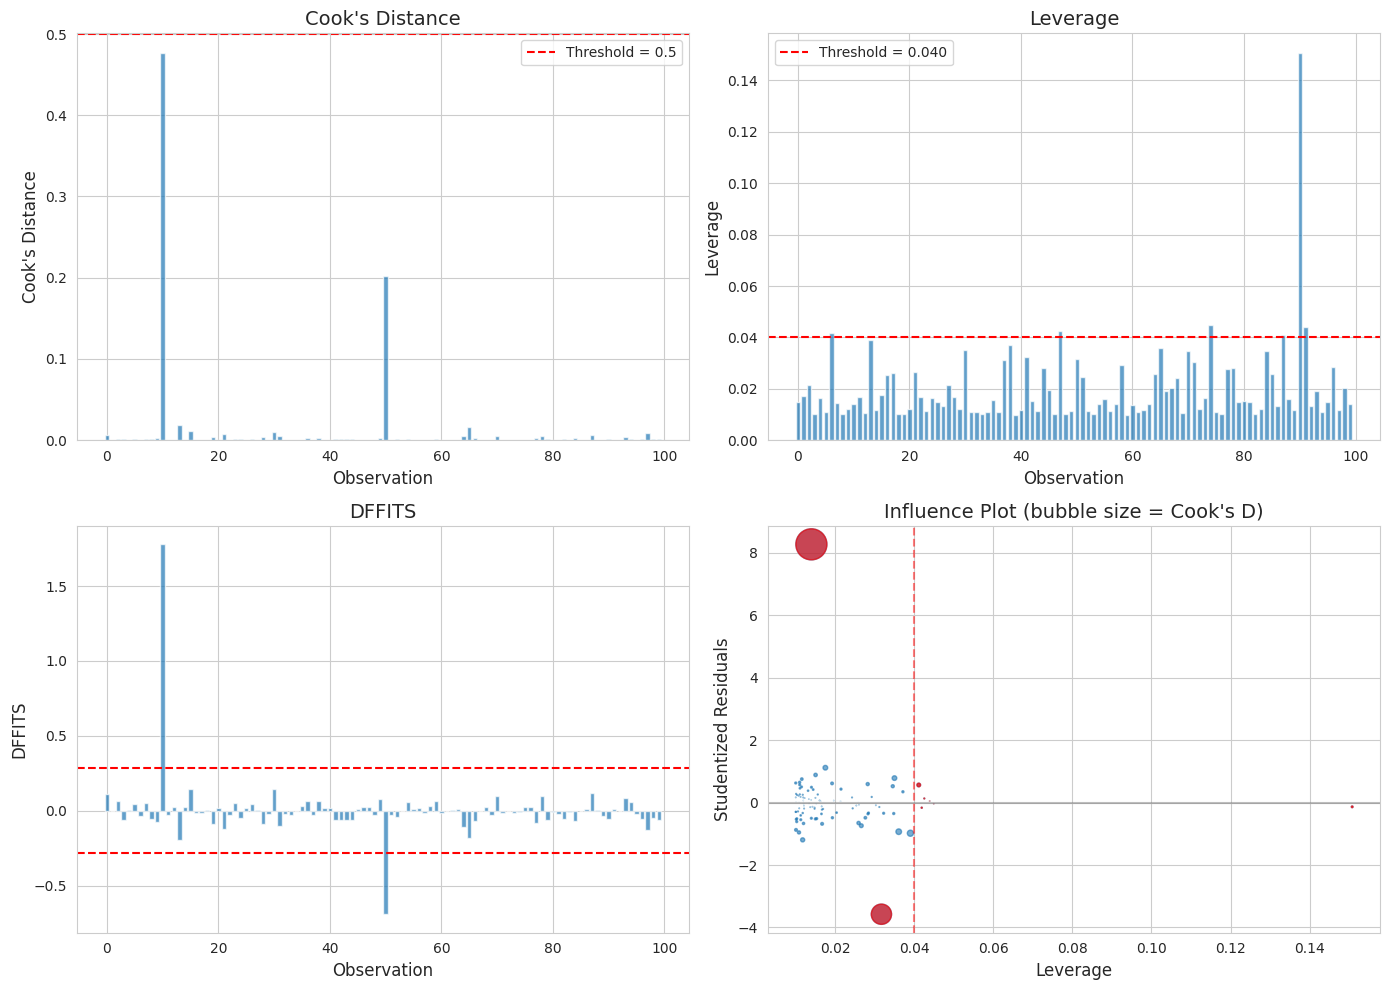

In [5]:
# 影響度の可視化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cook's distance
axes[0, 0].bar(range(n), cooks_d, alpha=0.7)
axes[0, 0].axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
axes[0, 0].set_xlabel('Observation', fontsize=12)
axes[0, 0].set_ylabel("Cook's Distance", fontsize=12)
axes[0, 0].set_title("Cook's Distance", fontsize=14)
axes[0, 0].legend()

# Leverage
axes[0, 1].bar(range(n), leverage, alpha=0.7)
axes[0, 1].axhline(leverage_threshold, color='red', linestyle='--', 
                    label=f'Threshold = {leverage_threshold:.3f}')
axes[0, 1].set_xlabel('Observation', fontsize=12)
axes[0, 1].set_ylabel('Leverage', fontsize=12)
axes[0, 1].set_title('Leverage', fontsize=14)
axes[0, 1].legend()

# DFFITS
axes[1, 0].bar(range(n), dffits, alpha=0.7)
axes[1, 0].axhline(dffits_threshold, color='red', linestyle='--')
axes[1, 0].axhline(-dffits_threshold, color='red', linestyle='--')
axes[1, 0].set_xlabel('Observation', fontsize=12)
axes[1, 0].set_ylabel('DFFITS', fontsize=12)
axes[1, 0].set_title('DFFITS', fontsize=14)

# Influence plot (residuals vs leverage, bubble size = Cook's D)
sizes = 500 * cooks_d / cooks_d.max()
axes[1, 1].scatter(leverage, int_student, s=sizes, alpha=0.6)
axes[1, 1].scatter(leverage[influential], int_student[influential], 
                   s=sizes[influential], color='red', alpha=0.6)
axes[1, 1].axhline(0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].axvline(leverage_threshold, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Leverage', fontsize=12)
axes[1, 1].set_ylabel('Studentized Residuals', fontsize=12)
axes[1, 1].set_title("Influence Plot (bubble size = Cook's D)", fontsize=14)

plt.tight_layout()
plt.show()

## 17.3 不均一分散の検定

### ブルーシュ・ペーガン検定
$$H_0: \sigma_i^2 = \sigma^2 \quad \text{vs} \quad H_1: \sigma_i^2 = f(\mathbf{x}_i^T\boldsymbol{\gamma})$$

検定統計量:
$$BP = nR^2 \sim \chi^2(p)$$

ここで $R^2$ は $e_i^2$ を説明変数に回帰したときの決定係数

### ホワイト検定
- 説明変数、その二乗、交差項を使用
- より一般的な不均一分散を検出

不均一分散の検定

ブルーシュ・ペーガン検定
  検定統計量 BP = 47.1340
  自由度 = 1
  p値 = 0.000000

結論: 不均一分散あり（α=0.05）


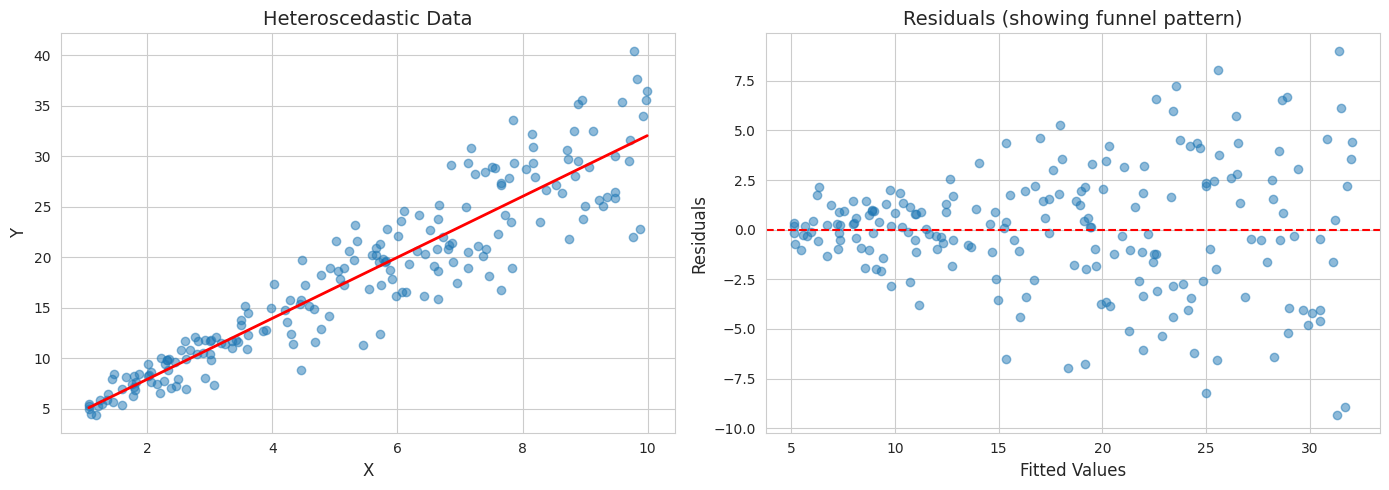

In [6]:
# 不均一分散データの生成
np.random.seed(456)

n = 200
X_het = np.random.uniform(1, 10, n)
# Variance increases with X
Y_het = 2 + 3*X_het + np.random.normal(0, 0.5*X_het, n)

# Fit regression
X_design_het = np.column_stack([np.ones(n), X_het])
beta_het = np.linalg.lstsq(X_design_het, Y_het, rcond=None)[0]
Y_hat_het = X_design_het @ beta_het
residuals_het = Y_het - Y_hat_het

# Breusch-Pagan test
def breusch_pagan_test(X, residuals):
    """Perform Breusch-Pagan test for heteroscedasticity."""
    n = len(residuals)
    
    # Squared residuals (scaled by MSE)
    e2 = residuals**2
    e2_scaled = e2 / np.mean(e2)
    
    # Regress scaled squared residuals on X
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    X_design = np.column_stack([np.ones(n), X])
    
    beta = np.linalg.lstsq(X_design, e2_scaled, rcond=None)[0]
    fitted = X_design @ beta
    
    # R-squared
    TSS = np.sum((e2_scaled - np.mean(e2_scaled))**2)
    RSS = np.sum((e2_scaled - fitted)**2)
    R2 = 1 - RSS/TSS
    
    # Test statistic
    BP = n * R2
    p = X.shape[1] if len(X.shape) > 1 else 1
    p_value = 1 - stats.chi2.cdf(BP, p)
    
    return BP, p_value, p

BP_stat, BP_pvalue, df = breusch_pagan_test(X_het, residuals_het)

print("不均一分散の検定")
print("="*50)
print(f"\nブルーシュ・ペーガン検定")
print(f"  検定統計量 BP = {BP_stat:.4f}")
print(f"  自由度 = {df}")
print(f"  p値 = {BP_pvalue:.6f}")
print(f"\n結論: {'不均一分散あり' if BP_pvalue < 0.05 else '不均一分散なし'}（α=0.05）")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(X_het, Y_het, alpha=0.5)
axes[0].plot(np.sort(X_het), beta_het[0] + beta_het[1]*np.sort(X_het), 
             'r-', linewidth=2)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_title('Heteroscedastic Data', fontsize=14)

# Residuals vs Fitted
axes[1].scatter(Y_hat_het, residuals_het, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residuals (showing funnel pattern)', fontsize=14)

plt.tight_layout()
plt.show()

等分散データでの検定

ブルーシュ・ペーガン検定
  検定統計量 BP = 1.1093
  p値 = 0.292232

結論: 等分散（α=0.05）


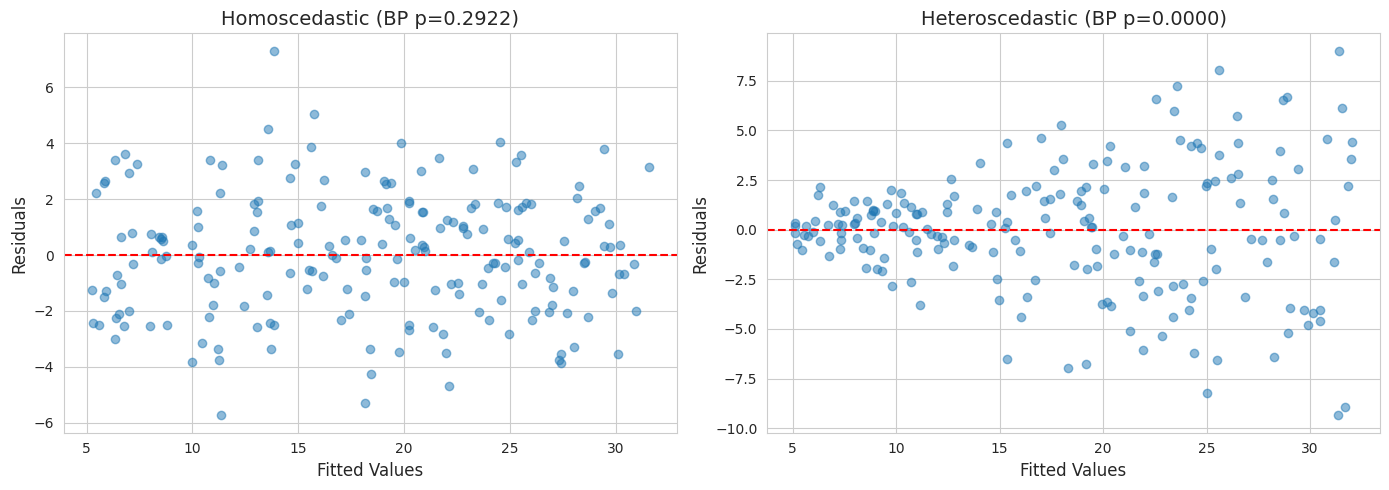

In [7]:
# 等分散データでの検定
np.random.seed(789)

# Homoscedastic data
X_hom = np.random.uniform(1, 10, n)
Y_hom = 2 + 3*X_hom + np.random.normal(0, 2, n)

# Fit and test
X_design_hom = np.column_stack([np.ones(n), X_hom])
beta_hom = np.linalg.lstsq(X_design_hom, Y_hom, rcond=None)[0]
Y_hat_hom = X_design_hom @ beta_hom
residuals_hom = Y_hom - Y_hat_hom

BP_stat_hom, BP_pvalue_hom, _ = breusch_pagan_test(X_hom, residuals_hom)

print("等分散データでの検定")
print("="*50)
print(f"\nブルーシュ・ペーガン検定")
print(f"  検定統計量 BP = {BP_stat_hom:.4f}")
print(f"  p値 = {BP_pvalue_hom:.6f}")
print(f"\n結論: {'不均一分散あり' if BP_pvalue_hom < 0.05 else '等分散'}（α=0.05）")

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_hat_hom, residuals_hom, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title(f'Homoscedastic (BP p={BP_pvalue_hom:.4f})', fontsize=14)

axes[1].scatter(Y_hat_het, residuals_het, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'Heteroscedastic (BP p={BP_pvalue:.4f})', fontsize=14)

plt.tight_layout()
plt.show()

## 17.4 正規性の検定

### シャピロ・ウィルク検定
- 小〜中標本に強力
- $H_0$: データは正規分布に従う

### ジャーク・ベラ検定
$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)$$

ここで $S$ は歪度、$K$ は尖度

- $H_0$ の下で $JB \sim \chi^2(2)$

正規性の検定

データ                     Shapiro p         JB p         歪度         尖度
----------------------------------------------------------------------
正規残差                       0.7488       0.8304      0.076      2.854
不均一分散残差                    0.0463       0.1680     -0.169      3.560
外れ値あり残差                    0.0000       0.0000      5.142     47.984


/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14475/393056434.py:61: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}

/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  

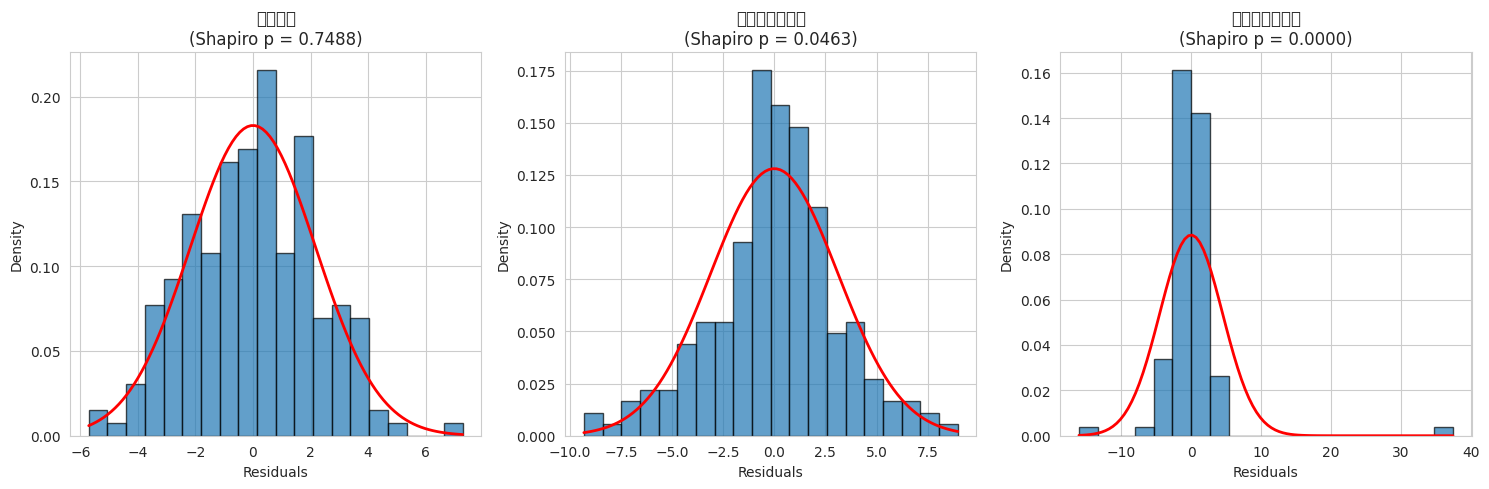

In [8]:
# 正規性の検定
def jarque_bera_test(data):
    """Perform Jarque-Bera test for normality."""
    n = len(data)
    
    # Calculate moments
    mean = np.mean(data)
    var = np.var(data, ddof=1)
    
    # Skewness and kurtosis
    m3 = np.mean((data - mean)**3)
    m4 = np.mean((data - mean)**4)
    
    skewness = m3 / (np.sqrt(var)**3)
    kurtosis = m4 / (var**2)
    
    # JB statistic
    JB = (n/6) * (skewness**2 + (kurtosis - 3)**2 / 4)
    p_value = 1 - stats.chi2.cdf(JB, 2)
    
    return JB, p_value, skewness, kurtosis

print("正規性の検定")
print("="*60)

# Test on different residuals
datasets = [
    ('正規残差', residuals_hom),
    ('不均一分散残差', residuals_het),
    ('外れ値あり残差', residuals)
]

print(f"\n{'データ':<20} {'Shapiro p':>12} {'JB p':>12} {'歪度':>10} {'尖度':>10}")
print("-"*70)

for name, data in datasets:
    # Shapiro-Wilk
    sw_stat, sw_p = stats.shapiro(data)
    
    # Jarque-Bera
    jb_stat, jb_p, skew, kurt = jarque_bera_test(data)
    
    print(f"{name:<20} {sw_p:>12.4f} {jb_p:>12.4f} {skew:>10.3f} {kurt:>10.3f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, data) in enumerate(datasets):
    axes[idx].hist(data, bins=20, density=True, alpha=0.7, edgecolor='black')
    
    # Overlay normal distribution
    x = np.linspace(data.min(), data.max(), 100)
    axes[idx].plot(x, stats.norm.pdf(x, np.mean(data), np.std(data)), 
                   'r-', linewidth=2, label='Normal fit')
    
    sw_stat, sw_p = stats.shapiro(data)
    axes[idx].set_title(f'{name}\n(Shapiro p = {sw_p:.4f})', fontsize=12)
    axes[idx].set_xlabel('Residuals', fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

## 17.5 練習問題

### 問題1
以下のデータで回帰分析を行い、影響力の大きい観測値を特定せよ。

X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 20]
Y = [3, 5, 7, 9, 11, 13, 15, 17, 19, 25]

### 問題2
問題1のデータについて:
(a) 10番目の観測値のてこ比を計算せよ
(b) クックの距離を計算せよ
(c) この観測値を除いた場合の回帰係数を求めよ

### 問題3
残差が以下の場合、不均一分散があるか視覚的に判断せよ。また、対処法を述べよ。

In [9]:
# 問題1の解答
print("問題1: 影響力の大きい観測値の特定")
print("="*50)

X_prob = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 20])
Y_prob = np.array([3, 5, 7, 9, 11, 13, 15, 17, 19, 25])
n = len(X_prob)

# Fit regression
X_design_prob = np.column_stack([np.ones(n), X_prob])
beta_prob = np.linalg.lstsq(X_design_prob, Y_prob, rcond=None)[0]
Y_hat_prob = X_design_prob @ beta_prob
residuals_prob = Y_prob - Y_hat_prob

# Calculate diagnostics
H_prob = X_design_prob @ np.linalg.inv(X_design_prob.T @ X_design_prob) @ X_design_prob.T
leverage_prob = np.diag(H_prob)
MSE_prob = np.sum(residuals_prob**2) / (n - 2)
std_res_prob = residuals_prob / np.sqrt(MSE_prob)
cooks_prob = (std_res_prob**2 / 2) * (leverage_prob / (1 - leverage_prob))

cooks_label = "Cook's D"
print(f"\n{'観測値':>8} {'X':>6} {'Y':>6} {'予測値':>8} {'残差':>8} {'てこ比':>8} {cooks_label:>10}")
print("-"*70)
for i in range(n):
    print(f"{i+1:>8} {X_prob[i]:>6} {Y_prob[i]:>6} {Y_hat_prob[i]:>8.2f} "
          f"{residuals_prob[i]:>8.2f} {leverage_prob[i]:>8.4f} {cooks_prob[i]:>10.4f}")

print(f"\n観測値10は高いてこ比（{leverage_prob[9]:.4f}）を持つレバレッジポイント")

問題1: 影響力の大きい観測値の特定

     観測値      X      Y      予測値       残差      てこ比   Cook's D
----------------------------------------------------------------------
       1      1      3     5.93    -2.93   0.2152     0.1783
       2      2      5     7.10    -2.10   0.1771     0.0723
       3      3      7     8.28    -1.28   0.1467     0.0214
       4      4      9     9.46    -0.46   0.1238     0.0022
       5      5     11    10.63     0.37   0.1086     0.0012
       6      6     13    11.81     1.19   0.1010     0.0120
       7      7     15    12.99     2.01   0.1010     0.0345
       8      8     17    14.17     2.83   0.1086     0.0743
       9      9     19    15.34     3.66   0.1238     0.1435
      10     20     25    28.29    -3.29   0.7943     3.1771

観測値10は高いてこ比（0.7943）を持つレバレッジポイント


In [10]:
# 問題2の解答
print("問題2: 影響度指標の詳細計算")
print("="*50)

# (a) Leverage for observation 10
print(f"\n(a) 10番目の観測値のてこ比: {leverage_prob[9]:.4f}")
print(f"    閾値 2(p+1)/n = {2*2/n:.4f}")
print(f"    → {'高いてこ比' if leverage_prob[9] > 2*2/n else '通常範囲'}")

# (b) Cook's distance
print(f"\n(b) クックの距離: {cooks_prob[9]:.4f}")
print(f"    → {'影響力大' if cooks_prob[9] > 0.5 else '影響力小'}")

# (c) Regression without observation 10
X_excl = X_prob[:-1]
Y_excl = Y_prob[:-1]
X_design_excl = np.column_stack([np.ones(n-1), X_excl])
beta_excl = np.linalg.lstsq(X_design_excl, Y_excl, rcond=None)[0]

print(f"\n(c) 観測値10を除いた場合の回帰係数:")
print(f"    全データ: Y = {beta_prob[0]:.4f} + {beta_prob[1]:.4f}*X")
print(f"    除外後:   Y = {beta_excl[0]:.4f} + {beta_excl[1]:.4f}*X")
print(f"\n    傾きの変化: {beta_prob[1] - beta_excl[1]:.4f}")

問題2: 影響度指標の詳細計算

(a) 10番目の観測値のてこ比: 0.7943
    閾値 2(p+1)/n = 0.4000
    → 高いてこ比

(b) クックの距離: 3.1771
    → 影響力大

(c) 観測値10を除いた場合の回帰係数:
    全データ: Y = 4.7486 + 1.1771*X
    除外後:   Y = 1.0000 + 2.0000*X

    傾きの変化: -0.8229


問題3: 不均一分散の診断と対処


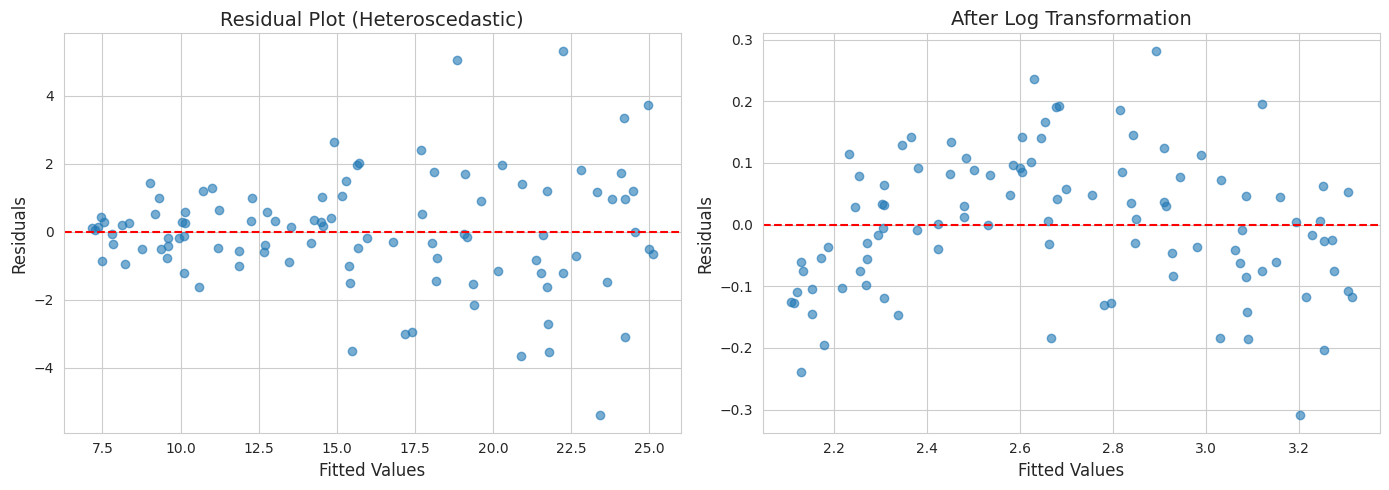


診断: 残差プロットにファネル形状が見られる → 不均一分散

対処法:
1. 変数変換（対数変換、平方根変換など）
2. 重み付き最小二乗法 (WLS)
3. ロバスト標準誤差の使用


In [11]:
# 問題3の解答と可視化
print("問題3: 不均一分散の診断と対処")
print("="*50)

# Generate heteroscedastic data
np.random.seed(111)
X_p3 = np.random.uniform(1, 10, 100)
Y_p3 = 5 + 2*X_p3 + np.random.normal(0, 0.3*X_p3, 100)

# Fit and get residuals
X_design_p3 = np.column_stack([np.ones(100), X_p3])
beta_p3 = np.linalg.lstsq(X_design_p3, Y_p3, rcond=None)[0]
residuals_p3 = Y_p3 - X_design_p3 @ beta_p3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_design_p3 @ beta_p3, residuals_p3, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residual Plot (Heteroscedastic)', fontsize=14)

# After log transformation
Y_log = np.log(Y_p3)
beta_log = np.linalg.lstsq(X_design_p3, Y_log, rcond=None)[0]
residuals_log = Y_log - X_design_p3 @ beta_log

axes[1].scatter(X_design_p3 @ beta_log, residuals_log, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('After Log Transformation', fontsize=14)

plt.tight_layout()
plt.show()

print("\n診断: 残差プロットにファネル形状が見られる → 不均一分散")
print("\n対処法:")
print("1. 変数変換（対数変換、平方根変換など）")
print("2. 重み付き最小二乗法 (WLS)")
print("3. ロバスト標準誤差の使用")

## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---